In [49]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

from network import FCN, Layer
from metrics import confusion_matrix, accuracy, plot_losses, summary

In [51]:
def show_digit(X, y, index):
    plt.imshow(X[index].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y[index])}")
    plt.axis('off')
    plt.show()

In [52]:
def one_hot(y, classes=10):
    encoded = np.zeros((len(y), classes))
    encoded[np.arange(len(y)), y] = 1
    return encoded

FCN initialized


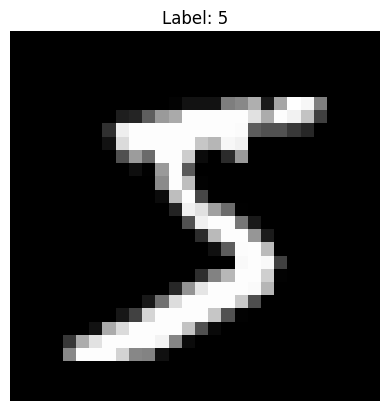

In [53]:
# initialize network with 2 hidden layers
network = FCN([
    Layer(784),
    Layer(128, 'relu'),
    Layer(64, 'relu'),
    Layer(10, 'softmax')
],
learning_rate=0.01,
loss = "cross_entropy")

# load mnist data and split into train and test partitions
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
y_train_full = one_hot(y_train_full)
y_test = one_hot(y_test)

# flatten each image from (28x28) to 784, then normalise to [0,1]
X_train_full = X_train_full.reshape(60000, 784) / 255.0
X_test  = X_test.reshape(10000, 784)  / 255.0

X_train, y_train = X_train_full[:50000], y_train_full[:50000]
X_val, y_val = X_train_full[50000:], y_train_full[50000:]



# test show a digit
show_digit(X_train, y_train, 0)



Model improved:
Epoch 1/25 - Loss: 0.0675 - Validation Loss: 1.9702 - Validation Accuracy: 43.10%
Model improved:
Epoch 2/25 - Loss: 0.0564 - Validation Loss: 1.6159 - Validation Accuracy: 61.90%
Model improved:
Epoch 3/25 - Loss: 0.0459 - Validation Loss: 1.2939 - Validation Accuracy: 71.08%
Model improved:
Epoch 4/25 - Loss: 0.0372 - Validation Loss: 1.0460 - Validation Accuracy: 76.78%
Model improved:
Epoch 5/25 - Loss: 0.0309 - Validation Loss: 0.8726 - Validation Accuracy: 80.24%
Model improved:
Epoch 6/25 - Loss: 0.0265 - Validation Loss: 0.7512 - Validation Accuracy: 82.85%
Model improved:
Epoch 7/25 - Loss: 0.0234 - Validation Loss: 0.6644 - Validation Accuracy: 84.51%
Model improved:
Epoch 8/25 - Loss: 0.0211 - Validation Loss: 0.6016 - Validation Accuracy: 85.58%
Model improved:
Epoch 9/25 - Loss: 0.0194 - Validation Loss: 0.5550 - Validation Accuracy: 86.21%
Model improved:
Epoch 10/25 - Loss: 0.0181 - Validation Loss: 0.5188 - Validation Accuracy: 86.84%
Model improved:
Epo

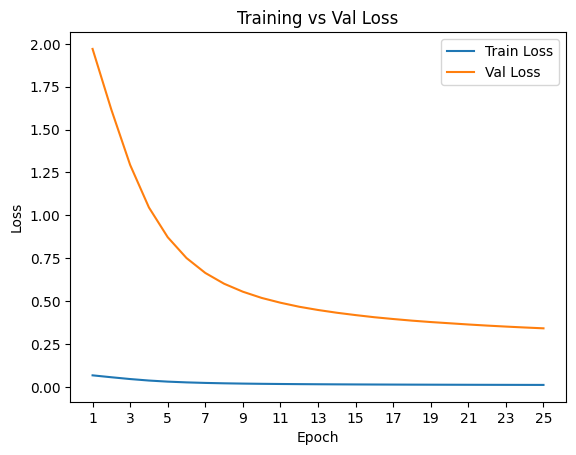

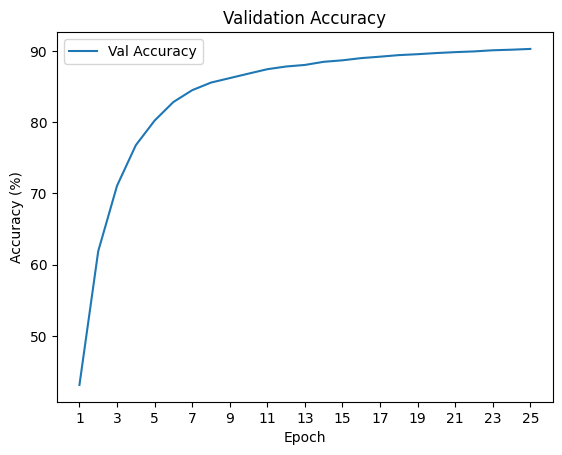

Test Accuracy: 90.11%


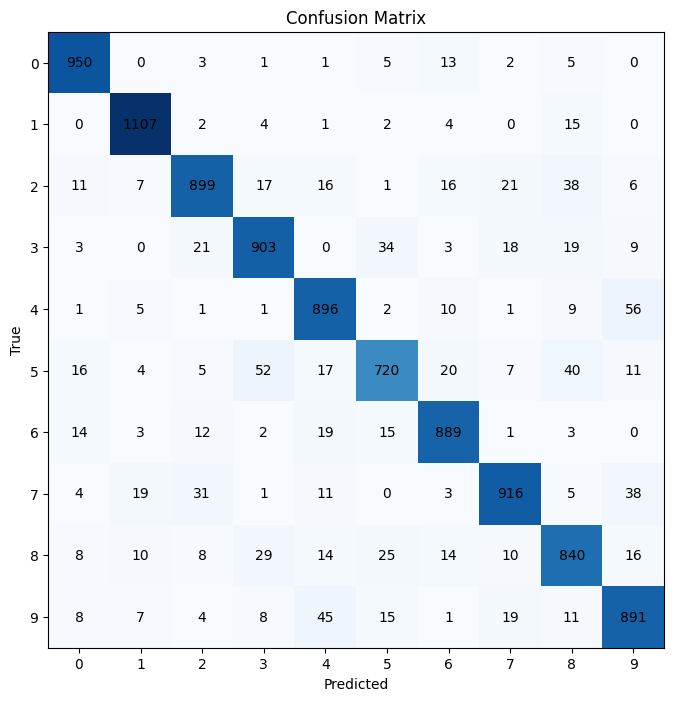

In [54]:
losses = network.train(X_train, y_train, X_val, y_val, epochs=25, batch_size=32)

# display some metrics
plot_losses(losses)
summary(network, X_test, y_test)

FCN initialized
Batch size 1: 97.74%
FCN initialized
Batch size 8: 92.11%
FCN initialized
Batch size 32: 80.69%
FCN initialized
Batch size 64: 48.08%
FCN initialized
Batch size 128: 16.85%
FCN initialized
Batch size 256: 6.81%
Batch sizes: [1, 8, 32, 64, 128, 256]


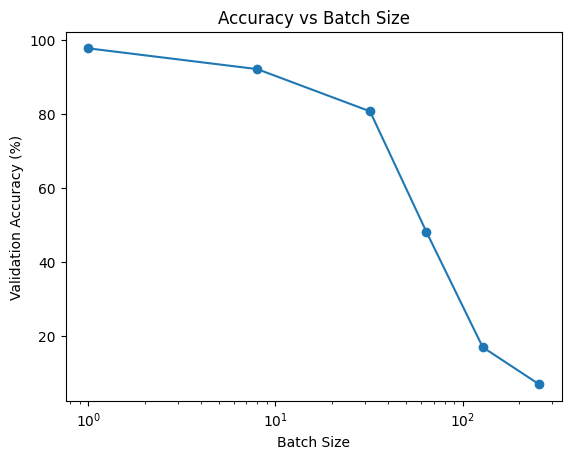

In [55]:
# testing batch_size
batch_sizes = [1, 8, 32, 64, 128, 256]
results = {}

for bs in batch_sizes:
    model = FCN([
        Layer(784),
        Layer(128, 'relu'),
        Layer(10, 'softmax')
    ], loss='cross_entropy', learning_rate=0.01)
    
    model.train(X_train, y_train, epochs=5, batch_size=bs)
    acc = accuracy(model, X_val, y_val)
    results[bs] = acc
    print(f"Batch size {bs}: {acc:.2f}%")

# plot
print("Batch sizes:", batch_sizes)
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xscale('log')
plt.xlabel('Batch Size')
plt.ylabel('Validation Accuracy (%)')
plt.title('Accuracy vs Batch Size')
plt.show()

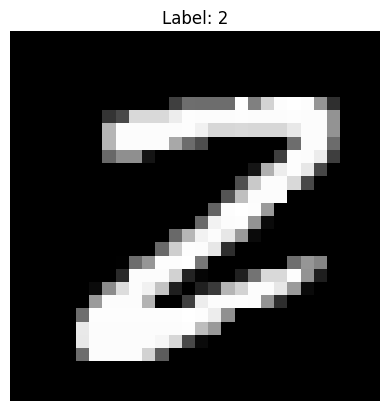

[0.0061 0.0002 0.5163 0.0186 0.     0.0043 0.0015 0.0001 0.4529 0.    ]
Prediction: 2


In [56]:
import random

index = random.randint(0, 9999)
show_digit(X_test, y_test, index)
np.set_printoptions(precision=4, suppress=True)
pred = network.predict(X_test[index])
print(pred)
print("Prediction:", np.argmax(pred))